# practice project

In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("C:/Users/DHEERAJ/Desktop/100DaysML/practice_projects/practice1/modified_placement_data.csv")

In [4]:
# just an overview of dataset( five five rows).
df.head()


,cgpa,iq,placement
0,"6,8",123.0,Yes
1,"5,9",106.0,No
2,"5,3",121.0,No
3,"7,4",132.0,Yes
4,"5,8",142.0,No


In [5]:
# just an overview of dataset ( last five rows).
df.tail()

,cgpa,iq,placement
95,"4,3",200.0,No
96,"4,4",42.0,No
97,"6,7",182.0,Yes
98,"6,3",103.0,Yes
99,"6,2",113.0,Yes


steps:-
0. preprocessing +EDA + Feature selection .
1. extract input and output cols
2. Scale the values
3. train test split
4. train the model
5. evaluate the model/model selection
6. deploy the model 

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     object 
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.5+ KB


In [7]:
# so it is showing five missing values in cgpa.
# 1. Impute with Median or Mean (Recommended)Since CGPA is numerical and likely skewed (or has outliers), the median is generally safer than the mean.python
# Fill missing CGPA values with the median of the column
# df['CGPA'].fillna(df['CGPA'].median(), inplace=True)


# 2. Drop the Rows (If Data is Large)If your dataset has hundreds or thousands of rows, dropping 5 rows won't significantly affect your analysis.python# Drop rows where CGPA is missing
# df.dropna(subset=['CGPA'], inplace=True)

# 3. Check Data Quality (Before Imputing)It is useful to see which rows are missing to understand if they are missing at random.python# View rows where CGPA is missing.
# print(df[df['CGPA'].isnull()])

df.isnull().sum()

cgpa         5
iq           0
placement    0
dtype: int64

In [9]:
# check data quality before imputation or dropping.

# Because IQ and Placement are so closely linked here, you can use Iterative Imputation or KNN Imputation instead of just filling with a simple mean. This uses the relationship between IQ/Placement to "guess" what the CGPA likely was for those students.For example, a student with a 166 IQ and a "Yes" placement probably had a higher CGPA than the student with a 66 IQ and "No" placement. Simple mean imputation would ignore this logic and give them both the same value.
# from sklearn.experimental import enable_iterative_imputer
# from sklearn.impute import IterativeImputer

# # Convert 'placement' to numbers first (0 and 1)
# df['placement'] = df['placement'].map({'Yes': 1, 'No': 0})

# # Impute CGPA based on IQ and Placement
# imputer = IterativeImputer()
# df[['cgpa', 'iq', 'placement']] = imputer.fit_transform(df[['cgpa', 'iq', 'placement']])


print(df[df['cgpa'].isnull()])

   cgpa     iq placement
9   NaN   66.0        No
54  NaN  141.0       Yes
81  NaN  107.0        No
85  NaN  166.0       Yes
91  NaN  158.0       Yes


In [11]:
# Convert cgpa values from strings with comma decimals to numeric,
# then fill missing cgpa values with the median.
df['cgpa'] = pd.to_numeric(df['cgpa'].str.replace(',', '.', regex=False), errors='coerce')
df['cgpa'].fillna(df['cgpa'].median(), inplace=True)


C:\Users\DHEERAJ\AppData\Local\Temp\ipykernel_34036\3293746567.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cgpa'].fillna(df['cgpa'].median(), inplace=True)


In [12]:
df.isnull().sum()

cgpa         0
iq           0
placement    0
dtype: int64

In [13]:
import matplotlib.pyplot as plt

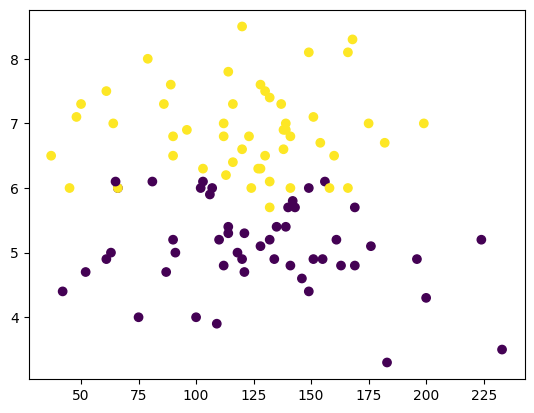

In [ ]:
plt.label()
plt.scatter(df['iq'],df['cgpa'], c=df['placement'].map({'Yes':1,'No':0},))